## Implementing simple Chatbot using LangGraph

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# Reducers
from typing import Annotated # it is annotation
from langgraph.graph.message import add_messages # it is reducer

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]  ## add_messages=> append the new messages

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o", temperature=0.9)
llm.invoke("What is the capital of France?")

In [7]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="llama-3.1-8b-instant", temperature=0.9)
llm_groq.invoke("What is the capital of France?")

AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 42, 'total_tokens': 50, 'completion_time': 0.007294934, 'completion_tokens_details': None, 'prompt_time': 0.001952201, 'prompt_tokens_details': None, 'queue_time': 0.047399928, 'total_time': 0.009247135}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea1c9-d645-7803-8b72-23080ff491d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 8, 'total_tokens': 50})

### Creating Nodes

In [ ]:
def superbot(state: State) -> str:
    return { "messages": [llm_groq.invoke(state['messages'])] }

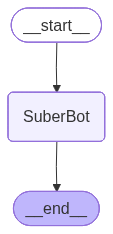

In [12]:
graph = StateGraph(State)

graph.add_node("SuberBot", superbot)
graph.add_edge(START, "SuberBot")
graph.add_edge("SuberBot", END)

graph_builder = graph.compile()

#display
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [13]:
# Invocation
graph_builder.invoke({ "messages": ["Who is Krish Nayak?"] })

{'messages': [HumanMessage(content='Who is Krish Nayak?', additional_kwargs={}, response_metadata={}, id='62c1271e-2efa-4841-9d5c-5d00bbf329ec'),
  AIMessage(content='I am unable to verify information about a person called Krish Nayak.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 41, 'total_tokens': 56, 'completion_time': 0.023068837, 'completion_tokens_details': None, 'prompt_time': 0.011138015, 'prompt_tokens_details': None, 'queue_time': 0.169541335, 'total_time': 0.034206852}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea1d1-cea5-7942-8a7d-d13f1a2e5649-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 15, 'total_tokens': 56})]}

STREAMING THE RESPONSES

In [17]:
for event in graph_builder.stream({ "messages": ["Who is tutor Krish Nayak in India?"] }, stream_mode="updates"):
    print(event)

{'SuberBot': {'messages': [AIMessage(content='I do not have any knowledge of a tutor named Krish Nayak in India.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 44, 'total_tokens': 61, 'completion_time': 0.111114922, 'completion_tokens_details': None, 'prompt_time': 0.003686075, 'prompt_tokens_details': None, 'queue_time': 0.047786464, 'total_time': 0.114800997}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea1d5-eacf-7c60-bcba-a7bc6bf36052-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 17, 'total_tokens': 61})]}}
